<a href="https://colab.research.google.com/github/JeffersonRodrigues9/Projetos-em-Machine-Learning/blob/main/reconhecimento_facial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# RECONHECIMENTO FACIAL E COMPARAÇÃO VETORIAL ---
# Instalação prévia

!pip install face-recognition opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 10.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=ff4665693f2194645c7ddddcc15419af7f2c1a6a42f00407a4fd104bf2c08231
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


[SISTEMA] Carregando imagem mestra e gerando vetor de 128 números...

[MATEMÁTICA] Distância calculada entre os rostos: 0.2717

--- Resultado da Análise de Biometria Facial ---


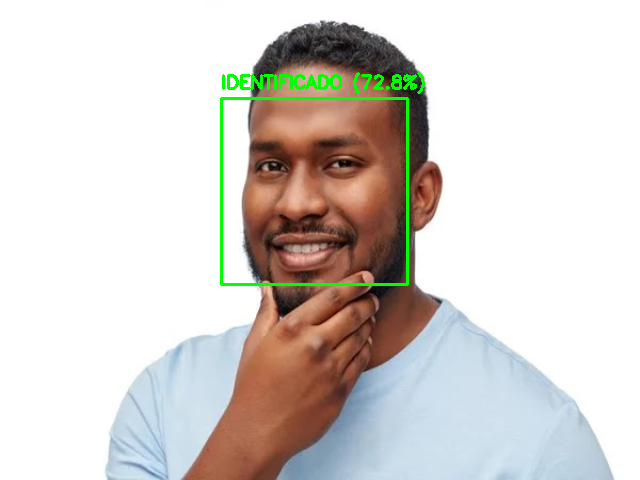

In [4]:
import cv2
import face_recognition
from google.colab.patches import cv2_imshow # Renderizador para o Colab

# 1. CARREGAR A REFERÊNCIA (O CADASTRO NO BANCO DE DADOS)
print("[SISTEMA] Carregando imagem mestra e gerando vetor de 128 números...")

# 2. A biblioteca carrega o arquivo e calcula a assinatura matemática (encoding)
foto_mestra = face_recognition.load_image_file("referencia.jpg")
encoding_referencia = face_recognition.face_encodings(foto_mestra)[0]


# 3. CARREGAR A FOTO DE TESTE (O CLIENTE TENTANDO SE IDENTIFICAR)
# Testar primeiro com 'teste_sucesso.jpg' e depois mudar para 'teste_desconhecido.jpg'
imagem_analise = cv2.imread("teste_sucesso.jpg")
imagem_analise = cv2.resize(imagem_analise, (640, 480))

# 4. Conversão obrigatória: face_recognition lê em RGB, mas o OpenCV lê em BGR
imagem_analise_rgb = cv2.cvtColor(imagem_analise, cv2.COLOR_BGR2RGB)

# 5. Localizar rostos na foto de teste e extrair seus encodings
locais_dos_rostos = face_recognition.face_locations(imagem_analise_rgb)
encodings_dos_rostos = face_recognition.face_encodings(imagem_analise_rgb, locais_dos_rostos)

# 6. Varre todos os rostos encontrados na foto de teste (caso haja mais de um)
for (topo, direita, fundo, esquerda), encoding_rosto_atual in zip(locais_dos_rostos, encodings_dos_rostos):

    # Calcular a distância matemática entre as duas assinaturas
    # Parâmetro: face_recognition.face_distance([vetor_salvo], vetor_atual)
    distancia = face_recognition.face_distance([encoding_referencia], encoding_rosto_atual)[0]
    print(f"\n[MATEMÁTICA] Distância calculada entre os rostos: {distancia:.4f}")

    # Lógica de Threshold (Limite de tolerância de mercado = 0.6)
    if distancia < 0.6:
        label_texto = f"IDENTIFICADO ({100 - (distancia*100):.1f}%)"
        cor_borda = (0, 255, 0) # Verde para sucesso
    else:
        label_texto = "DESCONHECIDO"
        cor_borda = (0, 0, 255) # Vermelho para intruso

    # 3. OpenCV entra em ação apenas para desenhar o feedback na tela
    cv2.rectangle(imagem_analise, (esquerda, topo), (direita, fundo), cor_borda, 2)
    cv2.putText(imagem_analise, label_texto, (esquerda, topo - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, cor_borda, 2)

# 7. Exibe o diagnóstico visual na tela do laboratório
print("\n--- Resultado da Análise de Biometria Facial ---")
cv2_imshow(imagem_analise)